# BUS 32120, Final Project

## ***What Drives Box Office Success? A Data-Driven Analysis of the Film Features That Shape Revenue and Profitability***

### By Vivian Yang and Amy Ma

## **Introduction**

This analysis is intended for film producers, studio executives, and investors who are looking for more insight into the factors that influence the financial success of a film. The film industry is a high-risk industry with a high-reward approach, and the financial success of a film can be heavily influenced by the spending, the timing of the release, the genres of the film, whether it wins awards, and the actors in the film.

The question that this research is aiming to answer is: **Which factors (genre, budget, release timing, famous director, famous cast) most influence movie revenue and profitability?** In order to answer this question, the analysis explores relationships between variables such as budget, popularity, ratings, genre, release timing, and star power using exploratory data analysis and predictive models. By understanding these relationships, the best decision can be made in terms of which movie is the right one to invest in and how it should be marketed.

## **Data Sources**

This analysis relied on two data sources.


1) The [TMDB + IMDB Merged Movies Dataset](https://www.kaggle.com/datasets/ggtejas/tmdb-imdb-merged-movies-dataset?resource=download), which contains over 400k records of movie attributes such as titles, release dates, ratings, genres, production companies, and more.

2)  The [Oscar Award Dataset](https://www.kaggle.com/datasets/unanimad/the-oscar-award/data), which contains a scrape of The Academy Awards Database, recorded of past Academy Award winners and nominees between 1927 and 2025.

Both of these data sources were downloaded as .csv and uploaded to Jupyter Notebook before beginning this analysis.


## **Importing Data/Packages**

In [186]:
import requests
import pandas as pd
import numpy as np
import time
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [187]:
movie_df = pd.read_csv('/content/TMDB  IMDB Movies Dataset.csv', engine='python', on_bad_lines='skip')
movie_df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,genres,production_companies,production_countries,spoken_languages,keywords,directors,writers,averageRating,numVotes,cast
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",Christopher Nolan,Christopher Nolan,8.8,2793340,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,...",Christopher Nolan,"Jonathan Nolan, Christopher Nolan",8.7,2491428,"Matthew McConaughey, Anne Hathaway, Michael Ca..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f...",Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Go...",9.1,3141794,"Christian Bale, Heath Ledger, Aaron Eckhart, M..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ...",James Cameron,James Cameron,7.9,1488308,"Sam Worthington, Zoe Saldaña, Sigourney Weaver..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com...",Joss Whedon,"Joss Whedon, Zak Penn",8.0,1549290,"Robert Downey Jr., Chris Evans, Mark Ruffalo, ..."


In [188]:
oscar_df = pd.read_csv('/content/Oscar Award Nominees Dataset.csv')
oscar_df.head()

,year_film,year_ceremony,ceremony,category,canon_category,name,film,winner
0,1927,1928,1,ACTOR,ACTOR IN A LEADING ROLE,Richard Barthelmess,The Noose,False
1,1927,1928,1,ACTOR,ACTOR IN A LEADING ROLE,Richard Barthelmess,The Patent Leather Kid,False
2,1927,1928,1,ACTOR,ACTOR IN A LEADING ROLE,Emil Jannings,The Last Command,True
3,1927,1928,1,ACTOR,ACTOR IN A LEADING ROLE,Emil Jannings,The Way of All Flesh,True
4,1927,1928,1,ACTRESS,ACTRESS IN A LEADING ROLE,Louise Dresser,A Ship Comes In,False


## **Quick Look**

In [189]:
movie_df.columns

Index(['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date',
       'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage',
       'tconst', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'tagline', 'genres',
       'production_companies', 'production_countries', 'spoken_languages',
       'keywords', 'directors', 'writers', 'averageRating', 'numVotes',
       'cast'],
      dtype='object')

In [190]:
movie_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 436003 entries, 0 to 436002
Data columns (total 29 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    436003 non-null  int64  
 1   title                 436003 non-null  object 
 2   vote_average          436003 non-null  float64
 3   vote_count            436003 non-null  int64  
 4   status                436003 non-null  object 
 5   release_date          414828 non-null  object 
 6   revenue               436003 non-null  int64  
 7   runtime               436003 non-null  int64  
 8   adult                 436003 non-null  bool   
 9   backdrop_path         185174 non-null  object 
 10  budget                436003 non-null  int64  
 11  homepage              54704 non-null   object 
 12  tconst                436003 non-null  object 
 13  original_language     436003 non-null  object 
 14  original_title        436003 non-null  object 
 15  

In [191]:
movie_df.describe()

,id,vote_average,vote_count,revenue,runtime,budget,popularity,averageRating,numVotes
count,4.360030e+05,436003.000000,436003.000000,4.360030e+05,436003.000000,4.360030e+05,436003.000000,436003.000000,4.360030e+05
mean,4.925961e+05,3.601751,48.877508,1.650918e+06,66.474357,6.485264e+05,2.195174,6.232025,3.087270e+03
std,3.625928e+05,3.149405,512.838333,2.616737e+07,63.896078,7.412646e+06,11.345564,1.309630,3.386718e+04
min,2.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,1.000000,5.000000e+00
25%,2.097725e+05,0.000000,0.000000,0.000000e+00,15.000000,0.000000e+00,0.600000,5.500000,2.300000e+01
50%,4.188030e+05,4.600000,1.000000,0.000000e+00,80.000000,0.000000e+00,0.855000,6.300000,6.900000e+01
75%,7.095725e+05,6.200000,6.000000,0.000000e+00,96.000000,0.000000e+00,1.658000,7.100000,3.160000e+02
max,1.646751e+06,10.000000,34495.000000,2.923706e+09,14400.000000,8.880000e+08,2994.357000,10.000000,3.164347e+06


In [192]:
oscar_df.columns

Index(['year_film', 'year_ceremony', 'ceremony', 'category', 'canon_category',
       'name', 'film', 'winner'],
      dtype='object')

In [193]:
oscar_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11110 entries, 0 to 11109
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   year_film       11110 non-null  int64 
 1   year_ceremony   11110 non-null  int64 
 2   ceremony        11110 non-null  int64 
 3   category        11110 non-null  object
 4   canon_category  11110 non-null  object
 5   name            11103 non-null  object
 6   film            10751 non-null  object
 7   winner          11110 non-null  bool  
dtypes: bool(1), int64(3), object(4)
memory usage: 618.6+ KB


## **Data Cleaning**


## Step 1: Filter and Remove Outliers

Drop Rows with Incomplete Data

In [194]:
movie_df.drop(movie_df.index[movie_df["runtime"] == 0], inplace=True)

In [195]:
movie_df.drop(movie_df.index[movie_df["budget"] == 0], inplace=True)

In [196]:
movie_df.drop(movie_df.index[movie_df["revenue"] == 0], inplace=True)

Drop Rows where Release Date is in the Past 3 Months (premature revenue data)

In [197]:
movie_df['release_date'] = pd.to_datetime(movie_df['release_date'], errors='coerce')
movie_df.drop(movie_df.index[movie_df['release_date'] >= pd.Timestamp('2025-11-08')], inplace=True)

Filter for movies released after 1980 (kept encountering RAM Issue)

In [198]:
movie_df['release_date'] = pd.to_datetime(movie_df['release_date'], errors='coerce')
movie_df = movie_df[(movie_df['release_date'].dt.year > 1980)]

In [199]:
oscar_df['year_film'] = pd.to_datetime(oscar_df['year_film'], format='%Y')
oscar_df = oscar_df[(oscar_df['year_film'].dt.year > 1980)]

## Step 2: Remove Missing Values

In [200]:
missing = movie_df.isnull().sum()
missing.name = "Missing Count"
missing

,Missing Count
id,0
title,0
vote_average,0
vote_count,0
status,0
release_date,0
revenue,0
runtime,0
adult,0
backdrop_path,586


In [201]:
drop_cols = ['backdrop_path', 'poster_path', 'overview', 'homepage', 'tagline']
movie_df = movie_df.drop(columns=drop_cols)

In [202]:
missing_value_cols = ['genres', 'production_companies', 'production_countries', 'spoken_languages', 'keywords', 'directors', 'writers', 'cast']
movie_df[missing_value_cols] = movie_df[missing_value_cols].fillna("Unknown")

In [203]:
missing = movie_df.isnull().sum()
missing.name = "Missing Count"
missing

,Missing Count
id,0
title,0
vote_average,0
vote_count,0
status,0
release_date,0
revenue,0
runtime,0
adult,0
budget,0


## Step 3: Normalize titles for both datasets

In [204]:
movie_df["title"] = (
    movie_df["title"]
    .str.lower()
    .str.strip()
    .str.replace(r"[^\w\s]", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
movie_df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,budget,...,genres,production_companies,production_countries,spoken_languages,keywords,directors,writers,averageRating,numVotes,cast
0,27205,inception,8.364,34495,Released,2010-07-15,825532764,148,False,160000000,...,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",Christopher Nolan,Christopher Nolan,8.8,2793340,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W..."
1,157336,interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,165000000,...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,...",Christopher Nolan,"Jonathan Nolan, Christopher Nolan",8.7,2491428,"Matthew McConaughey, Anne Hathaway, Michael Ca..."
2,155,the dark knight,8.512,30619,Released,2008-07-16,1004558444,152,False,185000000,...,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f...",Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Go...",9.1,3141794,"Christian Bale, Heath Ledger, Aaron Eckhart, M..."
3,19995,avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,237000000,...,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ...",James Cameron,James Cameron,7.9,1488308,"Sam Worthington, Zoe Saldaña, Sigourney Weaver..."
4,24428,the avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,220000000,...,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com...",Joss Whedon,"Joss Whedon, Zak Penn",8.0,1549290,"Robert Downey Jr., Chris Evans, Mark Ruffalo, ..."


In [205]:
oscar_df["film"] = (
    oscar_df["film"]
    .str.lower()
    .str.strip()
    .str.replace(r"[^\w\s]", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
oscar_df.head()

,year_film,year_ceremony,ceremony,category,canon_category,name,film,winner
5963,1981-01-01,1982,54,ACTOR IN A LEADING ROLE,ACTOR IN A LEADING ROLE,Warren Beatty,reds,False
5964,1981-01-01,1982,54,ACTOR IN A LEADING ROLE,ACTOR IN A LEADING ROLE,Henry Fonda,on golden pond,True
5965,1981-01-01,1982,54,ACTOR IN A LEADING ROLE,ACTOR IN A LEADING ROLE,Burt Lancaster,atlantic city,False
5966,1981-01-01,1982,54,ACTOR IN A LEADING ROLE,ACTOR IN A LEADING ROLE,Dudley Moore,arthur,False
5967,1981-01-01,1982,54,ACTOR IN A LEADING ROLE,ACTOR IN A LEADING ROLE,Paul Newman,absence of malice,False


In [206]:
movie_tidy = movie_df.copy() # creating a back-up version of the dataset to use later

In [209]:
movie_yearly_df = movie_df.copy() # creating versions of the dataframe with release time in year format for SQL analysis
movie_yearly_df['release_year'] = movie_df['release_date'].dt.year
movie_yearly_df = movie_yearly_df.drop(columns=['release_date'])
movie_yearly_df.head()

,id,title,vote_average,vote_count,status,revenue,runtime,adult,budget,tconst,...,production_companies,production_countries,spoken_languages,keywords,directors,writers,averageRating,numVotes,cast,release_year
0,27205,inception,8.364,34495,Released,825532764,148,False,160000000,tt1375666,...,"Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",Christopher Nolan,Christopher Nolan,8.8,2793340,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...",2010
1,157336,interstellar,8.417,32571,Released,701729206,169,False,165000000,tt0816692,...,"Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,...",Christopher Nolan,"Jonathan Nolan, Christopher Nolan",8.7,2491428,"Matthew McConaughey, Anne Hathaway, Michael Ca...",2014
2,155,the dark knight,8.512,30619,Released,1004558444,152,False,185000000,tt0468569,...,"DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f...",Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Go...",9.1,3141794,"Christian Bale, Heath Ledger, Aaron Eckhart, M...",2008
3,19995,avatar,7.573,29815,Released,2923706026,162,False,237000000,tt0499549,...,"Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ...",James Cameron,James Cameron,7.9,1488308,"Sam Worthington, Zoe Saldaña, Sigourney Weaver...",2009
4,24428,the avengers,7.710,29166,Released,1518815515,143,False,220000000,tt0848228,...,Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com...",Joss Whedon,"Joss Whedon, Zak Penn",8.0,1549290,"Robert Downey Jr., Chris Evans, Mark Ruffalo, ...",2012


In [210]:
oscar_yearly_df = oscar_df.copy()
oscar_yearly_df['release_year'] = oscar_df['year_film'].dt.year
oscar_yearly_df = oscar_yearly_df.drop(columns=['year_film'])
oscar_yearly_df.head()

,year_ceremony,ceremony,category,canon_category,name,film,winner,release_year
5963,1982,54,ACTOR IN A LEADING ROLE,ACTOR IN A LEADING ROLE,Warren Beatty,reds,False,1981
5964,1982,54,ACTOR IN A LEADING ROLE,ACTOR IN A LEADING ROLE,Henry Fonda,on golden pond,True,1981
5965,1982,54,ACTOR IN A LEADING ROLE,ACTOR IN A LEADING ROLE,Burt Lancaster,atlantic city,False,1981
5966,1982,54,ACTOR IN A LEADING ROLE,ACTOR IN A LEADING ROLE,Dudley Moore,arthur,False,1981
5967,1982,54,ACTOR IN A LEADING ROLE,ACTOR IN A LEADING ROLE,Paul Newman,absence of malice,False,1981


## Step 4: Separate Genre, Directors, Cast, Production Companies Rows

Creating exploded, tidy dataframes for each of these variables is useful for any analysis based on these variables.


In [211]:
movie_tidy_genre = movie_yearly_df.copy()
movie_tidy_genre["genre"] = movie_tidy_genre["genres"].str.split(", ")
movie_tidy_genre = movie_tidy_genre.explode("genre")
movie_tidy_genre = movie_tidy_genre.drop(columns=['genres'])

In [212]:
movie_tidy_director = movie_yearly_df.copy()
movie_tidy_director["director"] = movie_tidy_director["directors"].str.split(", ")
movie_tidy_director = movie_tidy_director.explode("director")
movie_tidy_director = movie_tidy_director.drop(columns=['directors'])

In [213]:
movie_tidy_cast = movie_yearly_df.copy()
movie_tidy_cast["ind_cast"] = movie_tidy_cast["cast"].str.split(", ")
movie_tidy_cast = movie_tidy_cast.explode("ind_cast")
movie_tidy_cast = movie_tidy_cast.drop(columns=['cast'])

In [214]:
movie_tidy_prod = movie_yearly_df.copy()
movie_tidy_prod["production_company"] = movie_tidy_prod["production_companies"].str.split(", ")
movie_tidy_prod = movie_tidy_prod.explode("production_company")
movie_tidy_prod = movie_tidy_prod.drop(columns=['production_companies'])

In [215]:
movie_tidy["genres"] = movie_tidy["genres"].str.split(", ")
movie_tidy = movie_tidy.explode("genres")

movie_tidy["directors"] = movie_tidy["directors"].str.split(", ")
movie_tidy = movie_tidy.explode("directors")

movie_tidy["writers"] = movie_tidy["writers"].str.split(", ")
movie_tidy = movie_tidy.explode("writers")

movie_tidy["cast"] = movie_tidy["cast"].str.split(", ")
movie_tidy = movie_tidy.explode("cast")

# **Analysis Part 1: Python EDA**

## Step 1: Feature engineering for Analysis

In [216]:
movie_df["profit"] = movie_df["revenue"] - movie_df["budget"]
movie_df["roi"] = movie_df["profit"] / movie_df["budget"]
movie_df["release_year"] = pd.to_datetime(movie_df["release_date"]).dt.year
movie_df["release_month"] = pd.to_datetime(movie_df["release_date"]).dt.month
movie_tidy["profit"] = movie_df["revenue"] - movie_df["budget"]
movie_tidy["roi"] = movie_df["profit"] / movie_df["budget"]
movie_tidy["release_year"] = pd.to_datetime(movie_df["release_date"]).dt.year
movie_tidy["release_month"] = pd.to_datetime(movie_df["release_date"]).dt.month

## Graph 1: Distribution of revenue

Show how movie revenue is distributed, so the audience understands whether success is concentrated in a few hit films

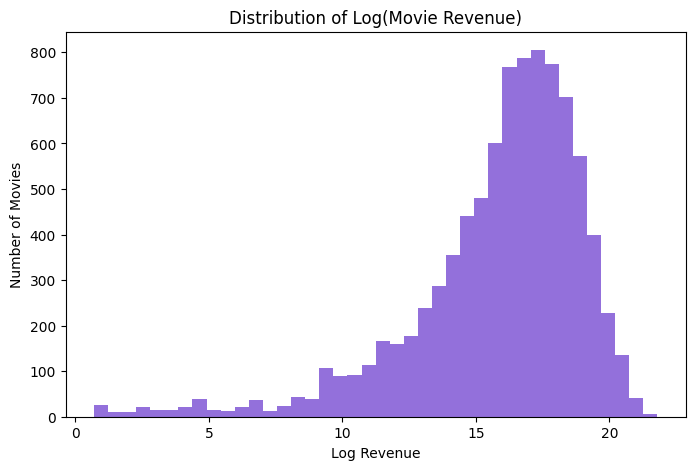

In [218]:
plt.figure(figsize=(8,5))
plt.hist(np.log1p(movie_df["revenue"]), bins=40, color="mediumpurple")
plt.title("Distribution of Log(Movie Revenue)")
plt.xlabel("Log Revenue")
plt.ylabel("Number of Movies")
plt.show()

As the revenue is log-scaled, the distribution of revenue indicates that the uneven distribution of the financial results of the movies and is the reason why the filmmaker should understand the factors that can increase the revenue and profitability of the film, thereby increasing the chances of success.

## Table 1: Revenue/profit summary statistics

Give a numerical overview of revenue, budget, profit, and ROI

In [219]:
summary_table = movie_df[["budget", "revenue", "profit", "roi"]].agg(["mean", "median", "min", "max"])
summary_table

,budget,revenue,profit,roi
mean,2.628250e+07,7.234176e+07,4.605926e+07,2.731752e+03
median,1.200000e+07,1.501853e+07,2.576158e+06,6.147814e-01
min,1.000000e+00,1.000000e+00,-1.995460e+08,-9.999990e-01
max,4.600000e+08,2.923706e+09,2.686706e+09,3.398367e+06


The average film budget is 31.7 million dollars and earns 88.6 million dollars in revenue on average, so the average movie makes more than the cost of the film. However, when looking at the median, revenue is only 19.8 million dollars and profit is only 5 million dollars, which are well below the average. This is likely due to the fact that the average is skewed by the high-revenue blockbusters. This reinforces why the film producers should be concerned with the factors that increase revenue and profit, such as the budget of the film, the type of film, the time of release, and the presence of famous directors and actors.

## Graph 2: Budget vs revenue

Test whether spending more is associated with higher box office revenue

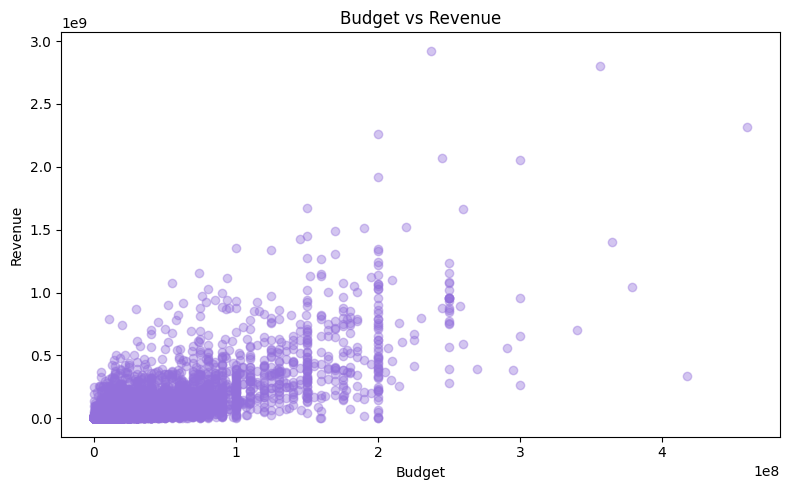

In [220]:
plt.figure(figsize=(8, 5))
plt.scatter(movie_df["budget"], movie_df["revenue"], alpha=0.4, color="mediumpurple")
plt.title("Budget vs Revenue")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

The scatter plot shows a general positive relationship between budget and revenue, suggesting that higher-budget films tend to generate higher box office revenue. However, the large spread of points on the plot indicates that budget alone does not guarantee success, meaning that other factors may also influence movie revenue and profitability.

## Graph 3: Budget vs ROI

Check whether bigger budgets also generate better returns relative to cost

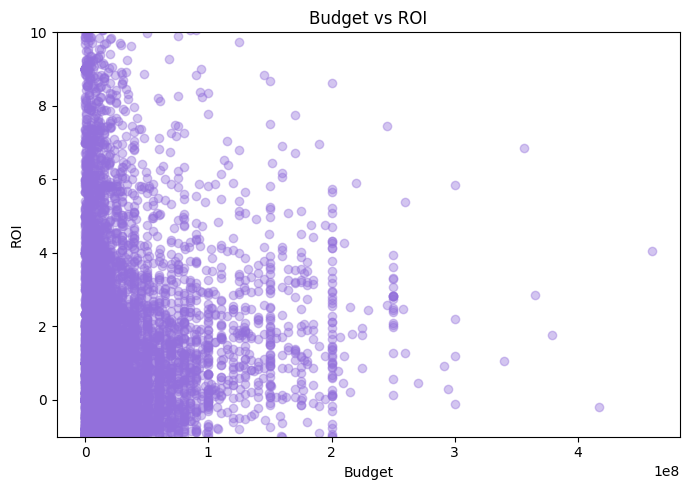

In [221]:
plt.figure(figsize=(7,5))
plt.scatter(movie_df["budget"], movie_df["roi"], alpha=0.4, color="mediumpurple")

plt.ylim(-1,10)   # limit ROI range so most points are visible

plt.title("Budget vs ROI")
plt.xlabel("Budget")
plt.ylabel("ROI")

plt.tight_layout()
plt.show()

The scatter plot shows that low-budget films tend to have a wider range of ROI, including some very high returns, while high-budget films generally have more moderate ROI values. This suggests that even though larger budgets may generate higher revenue, they don't necessarily guarantee higher profitability.

## Table 2: Average ROI by budget bucket

Turn the scatter into an easier summary

In [222]:
movie_df["budget_bucket"] = pd.qcut(
    movie_df["budget"],
    q=3,
    labels=["Low Budget", "Mid Budget", "High Budget"]
)

roi_by_budget = movie_df.groupby("budget_bucket")[["roi", "revenue", "profit"]].mean()
roi_by_budget

/tmp/ipykernel_593/2003823321.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  roi_by_budget = movie_df.groupby("budget_bucket")[["roi", "revenue", "profit"]].mean()


,roi,revenue,profit
budget_bucket,,,
Low Budget,8192.012634,7.307646e+06,5.495214e+06
Mid Budget,1.754009,3.478970e+07,2.206196e+07
High Budget,1.487284,1.759293e+08,1.112534e+08


The table shows that high-budget movies generate the highest average revenue and profit, while low-budget films have the highest average ROI. This indicates that although high-budget productions tend to earn more  money in total, smaller-budget films can be more efficient investments relative to their cost. For producers, this means budget influences success in two different ways: higher budgets may increase revenue potential, but lower budgets may offer better profitability.

## Graph 4: Average revenue by genre

Show which genres tend to earn the most revenue

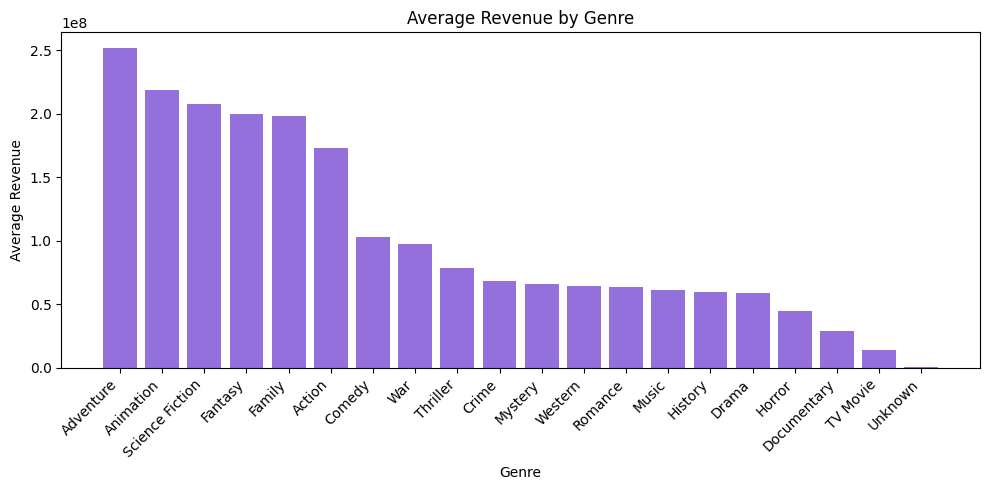

In [223]:
genre_revenue = (
    movie_tidy.groupby("genres")[["revenue"]]
    .mean()
    .sort_values("revenue", ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 5))
plt.bar(genre_revenue["genres"], genre_revenue["revenue"], color="mediumpurple")
plt.title("Average Revenue by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The chart shows that Adventure and Science Fiction films generate the highest average revenue, while genres like Documentary and TV Movie earn significantly less. This suggests that genre plays an important role in revenue potential and indicates that choosing a high-performing genre may significantly increase the likelihood of higher box office revenue.

## Graph 5: Average ROI by genre

Show which genres are most profitable relative to cost, not just biggest in revenue

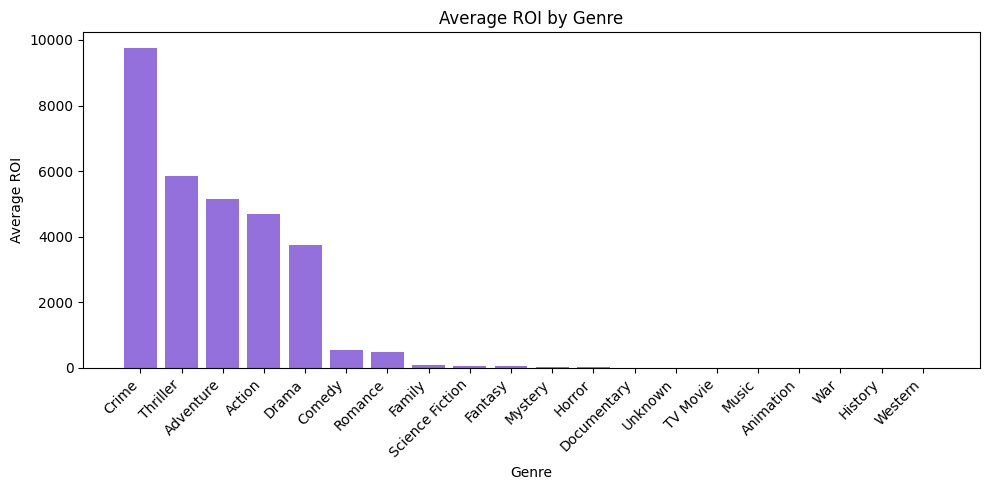

In [224]:
genre_roi = (
    movie_tidy.groupby("genres")[["roi"]]
    .mean()
    .sort_values("roi", ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 5))
plt.bar(genre_roi["genres"], genre_roi["roi"], color="mediumpurple")
plt.title("Average ROI by Genre")
plt.xlabel("Genre")
plt.ylabel("Average ROI")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

While genres such as Comedy, Romance, and Drama have extremely high average ROI, this likely reflects that these films have lower budgets but can still generate strong returns. In contrast, genres like Adventure and Science Fiction may generate high revenue but lower ROI because of their large production costs. This indicates that genre influences profitability differently from revenue, which producers should consider when deciding between high-budget hit films and smaller production movies.

## Table 3: Genre Financial Summary

Summarize genre performance numerically

In [225]:
genre_table = (
    movie_tidy.groupby("genres")[["budget", "revenue", "profit", "roi"]]
    .mean()
    .sort_values("roi", ascending=False)
)
genre_table

,budget,revenue,profit,roi
genres,,,,
Crime,2.829589e+07,6.868541e+07,4.038952e+07,9743.566756
Thriller,3.209933e+07,7.870157e+07,4.660224e+07,5850.173448
Adventure,7.440103e+07,2.513322e+08,1.769311e+08,5148.838523
Action,5.695859e+07,1.732595e+08,1.163009e+08,4684.003972
Drama,2.246791e+07,5.877155e+07,3.630365e+07,3750.598499
Comedy,3.247617e+07,1.026915e+08,7.021532e+07,556.287794
Romance,2.155249e+07,6.328445e+07,4.173196e+07,493.629518
Family,6.002377e+07,1.983765e+08,1.383527e+08,103.199937
Science Fiction,6.629754e+07,2.071926e+08,1.408950e+08,52.129162


The table confirms that genres such as Comedy, Romance, and Drama show the highest average ROI, while Adventure and Science Fiction genres generate higher total revenue but more moderate ROI. This suggests that large-budget genres drive revenue, but smaller-budget genres may produce better profitability relative to investment. This highlights the tradeoff between maximizing box office revenue versus maximizing return on investment.

## Graph 6: Average revenue by release month

Show whether some release timings perform better

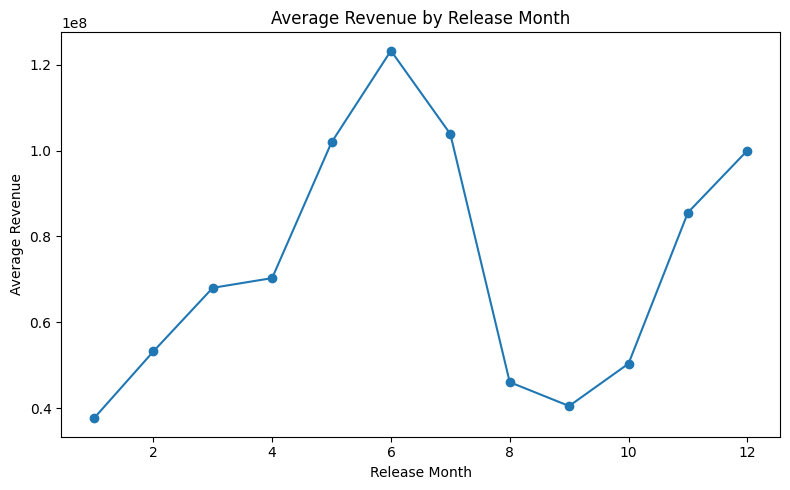

In [226]:
month_revenue = (
    movie_df.groupby("release_month")[["revenue"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
plt.plot(month_revenue["release_month"], month_revenue["revenue"], marker="o")
plt.title("Average Revenue by Release Month")
plt.xlabel("Release Month")
plt.ylabel("Average Revenue")
plt.tight_layout()
plt.show()

The line chart shows that movies released in May, June, July, and December generate the highest average revenue. This pattern reflects major industry release strategies such as summer break and holiday season releases. Therefore, release timing appears to be an important factor influencing revenue, suggesting that it may be beneficial to schedule releases during peak periods in the movie industry.

## Defining "Famous"

Using the Oscar dataset, define “famous” as Oscar-winning

In [227]:
oscar_directors = set()
oscar_actors = set(oscar_df["name"].dropna().str.lower())

movie_df["has_famous_cast"] = movie_df["cast"].fillna("").str.lower().apply(
    lambda x: any(actor in x for actor in oscar_actors)
)

## Graph 7: Famous cast vs average revenue

Look at whether movies with award-recognized casts earn more

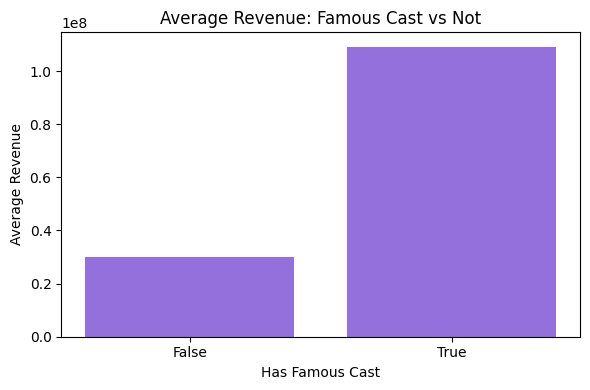

In [228]:
cast_fame_table = (
    movie_df.groupby("has_famous_cast")[["revenue", "roi"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6, 4))
plt.bar(cast_fame_table["has_famous_cast"].astype(str), cast_fame_table["revenue"], color="mediumpurple")
plt.title("Average Revenue: Famous Cast vs Not")
plt.xlabel("Has Famous Cast")
plt.ylabel("Average Revenue")
plt.tight_layout()
plt.show()

Movies with a famous cast generate significantly higher average revenue compared to those without well-known actors. This suggests that famous casts help attract larger audiences and increase box office performance. Thus, investing in recognizable actors could be an effective strategy for boosting revenue potential.

## Graph 8: Correlation heatmap

Show the overall relationships among the key numeric variables

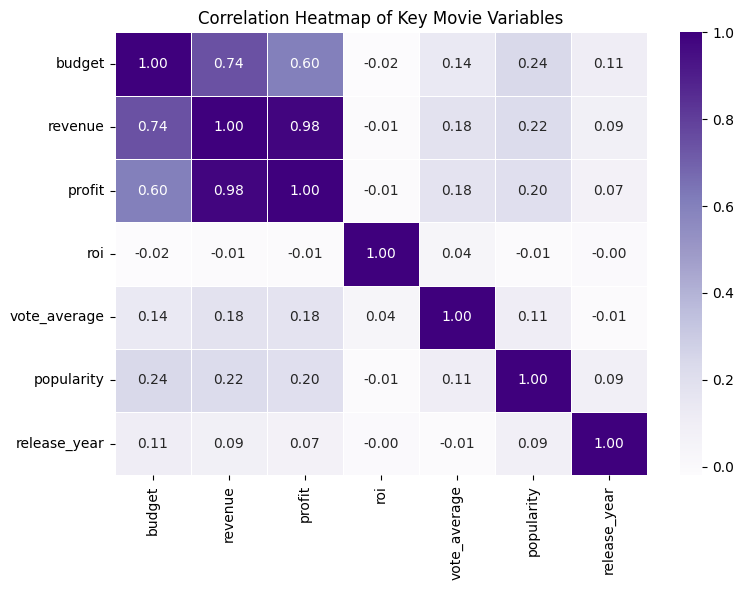

In [229]:
import seaborn as sns

corr_cols = ["budget", "revenue", "profit", "roi", "vote_average", "popularity", "release_year"]
corr_df = movie_df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="Purples", linewidths=0.5)
plt.title("Correlation Heatmap of Key Movie Variables")
plt.tight_layout()
plt.show()

The heatmap shows a strong positive correlation between budget and revenue (0.76) and between revenue and profit (0.98), indicating that higher-budget films tend to generate higher total revenue. However, ROI shows almost no correlation with budget, strengthening earlier findings that bigger budgets do not necessarily lead to higher profitability.

# Models

## Model 1: Linear Regression

Predicting revenue

In [230]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Make sure these columns exist in movie_tidy
movie_tidy["has_famous_cast"] = movie_tidy["cast"].fillna("").str.lower().apply(
    lambda x: any(actor in x for actor in oscar_actors)
)

movie_tidy["release_month"] = pd.to_datetime(movie_tidy["release_date"]).dt.month

# Create genre dummy variables
genre_dummies = pd.get_dummies(movie_tidy["genres"], prefix="genre")

# Build modeling dataframe
model_df = pd.concat([
    movie_tidy[[
        "budget",
        "popularity",
        "vote_average",
        "release_month",
        "has_famous_cast",
        "revenue"
    ]],
    genre_dummies
], axis=1)

# Drop missing values just in case
model_df = model_df.dropna()

# Features and target
X = model_df.drop(columns=["revenue"])
y = model_df["revenue"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
pred = model.predict(X_test)

# Metrics
print("R-squared:", r2_score(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

R-squared: 0.5929514880945472
RMSE: 153609202.6979271


The linear regression model explains about 59% of the variation in movie revenue (R² = 0.59) using factors such as budget, popularity, ratings, release timing, famous cast, and genre. This suggests that these production and market-related factors play a meaningful role in predicting box office performance. The results indicate that factors like popularity and star power can significantly influence revenue outcomes, although other unobserved factors may still affect profitability.

## Model 2: Logistic Regression

Predicting Hit Movies

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Create hit movie variable
movie_df["hit_movie"] = movie_df["revenue"] > movie_df["revenue"].median()

# Features
features = movie_df[[
    "budget",
    "popularity",
    "vote_average",
    "release_month",
    "has_famous_cast"
]]

target = movie_df["hit_movie"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
pred = model.predict(X_test)

# Metrics
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.8129370629370629
              precision    recall  f1-score   support

       False       0.78      0.86      0.82       561
        True       0.85      0.77      0.81       583

    accuracy                           0.81      1144
   macro avg       0.82      0.81      0.81      1144
weighted avg       0.82      0.81      0.81      1144



The logistic regression model predicts the success of the movie with an approximate accuracy level of 81%. This means that the selected features are significant predictors. The precision and recall levels are relatively balanced for both outcomes, which means that the model is good at detecting both success and failure. This is in line with the research question since some features are used to predict success despite other unpredictable factors.

# **Analysis Part 2: SQL**

## Initiate SQLite


In [231]:
import sqlite3
conn = sqlite3.connect('/content/movies.db')
movie_yearly_df.to_sql('movies', conn, if_exists='replace', index=False)
movie_tidy_cast.to_sql('movie_cast', conn, if_exists='replace', index=False)
movie_tidy_genre.to_sql('movie_genre', conn, if_exists='replace', index=False)
movie_tidy_director.to_sql('movie_director', conn, if_exists='replace', index=False)
movie_tidy_prod.to_sql('movie_prod', conn, if_exists='replace', index=False)
oscar_yearly_df.to_sql('oscars', conn, if_exists='replace', index=False)

5147

In [232]:
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master;")
print(cursor.fetchall())

[('movies',), ('movie_cast',), ('movie_genre',), ('movie_director',), ('movie_prod',), ('oscars',)]


# SQL Analysis


---


# Do production companies earn higher revenue after their first Oscar win?
## SQL Query 1: Groupby, Inner Join, Subquery

**Purpose**

This query compares each production company’s average movie revenue before and after the year of its first Oscar win. This helps evaluate whether an initial Oscar win is associated with a shift in the commercial performance of that company’s films over time. This is a useful first query to have as it **legitimizes the remainder of this analysis:** it is worth it for a producer to think about Oscar awards as there is indeed a correlation between winning one and having more commercial success.

**Methodology/Annotations**

A subquery finds each production company’s first_win_year by joining movie_prod to oscars, filtering to winning films, and taking the earliest release year for each company. That benchmark is then joined back to all films by the same company and the average revenue before and after the first win year is calculated.

**SELECT fw.production_company:** final result should have one row per production company.

**fw:** the alias for the subquery below, an acronym of “first win.”

**First AVG block:** CASE checks each movie row, and if the movie's release_year is earlier than the company's first_win_year, it returns that movie's revenue or NULL oithers. The AVG() function then averages all of them to give the average revenue of movies released before the first Oscar win.

**Second AVG block:** CASE checks each movie row, and if the movie's release_year is later than the company's first_win_year, it returns that movie's revenue or NULL oithers. The AVG() function then averages all of them to give the average revenue of movies released after the first Oscar win.

**FROM:** Starts a subquery

**SELECT..FROM block:** Selects the company name and the earliest release year among its Oscar-winning films via the MIN() function from the movie_prod dataframe. mp is the alias given to movie_prod.

**Subquery INNER JOIN block:** Matches the movie title to the Oscar film title. An inner join was used because we only care about movies that are in the oscars databse. o is the alias given to oscars.

**WHERE block:**: Filters joined rows so that only Oscar-winning films (not just nominated) are included and production company can't be null

**GROUP BY block:** This groups the rows by production company

**Main INNER JOIN block:** Takes the temporary fw table and joins it to every movie row for that company

**WHERE block:** Filters out null stuff

**GROUP BY:** Groups all the rows that have the same production company

**HAVING block:** Filters to keep companies that have one movie before the first win year and one movie afterwards, so that the outputs calculated won't be null

**ORDER BY:** Sorts the results from highest to lowest average revenue after win

In [233]:
query_prod_before_after = """
SELECT
    fw.production_company,
    AVG(
        CASE
            WHEN mp.release_year < fw.first_win_year
            THEN mp.revenue
        END
    ) AS avg_revenue_before_win,
    AVG(
        CASE
            WHEN mp.release_year > fw.first_win_year
            THEN mp.revenue
        END
    ) AS avg_revenue_after_win
FROM (
    SELECT
        mp.production_company,
        MIN(mp.release_year) AS first_win_year
    FROM movie_prod mp
    INNER JOIN oscars o
        ON mp.title = o.film
    WHERE o.winner = 1
    GROUP BY mp.production_company
) fw
INNER JOIN movie_prod mp
    ON mp.production_company = fw.production_company
GROUP BY fw.production_company
ORDER BY avg_revenue_after_win DESC;
"""
prod_before_after = pd.read_sql_query(query_prod_before_after, conn) # uses the Pandas real_sql method to process the query
prod_before_after.head(30) # output is exhibited in a dataframe called prod_before_after

,production_company,avg_revenue_before_win,avg_revenue_after_win
0,Fairview Entertainment,2.815745e+08,1.663075e+09
1,Joint Effort,8.623452e+07,1.074458e+09
2,Lightstorm Entertainment,NaN,1.012340e+09
3,Marvel Studios,7.420200e+08,1.008047e+09
4,Second Mate Productions,NaN,9.610000e+08
5,Pascal Pictures,3.370920e+08,8.920963e+08
6,LuckyChap Entertainment,NaN,8.169589e+08
7,Illumination,6.387933e+08,7.327723e+08
8,WingNut Films,8.912744e+06,6.851807e+08
9,Syncopy,1.613145e+08,6.754477e+08


In [234]:
print("Average revenue before win:", prod_before_after.avg_revenue_before_win.mean())
print("Average revenue after win:", prod_before_after.avg_revenue_after_win.mean())
print(f"Post win revenue premium: {prod_before_after.avg_revenue_after_win.mean() / prod_before_after.avg_revenue_before_win.mean()}x")

Average revenue before win: 71436344.56412286
Average revenue after win: 102429885.15365833
Post win revenue premium: 1.4338623536610973x


The average post-win revenue is roughly **43.4% higher** than the average pre-win revenue for these production companies, suggesting a positive association between an initial Oscar win and later box office performance.

# Which films got the most nominations?
## SQL Query 2: Groupby

**Purpose**

This query identifies which films received the most Oscar nominations and how many of those nominations resulted in wins. This helps highlight the most recognized films in the Oscars dataset as we begin our analysis.

**Methodology/Annotations**

The query groups the oscars table by film title so that each film is summarized into a single row. It then uses COUNT(*) to calculate total nominations and SUM(o.winner) to calculate total wins, ordering the results first by nomination count and then by win count in descending order.

**COUNT(*)** Counts how many rows each film has in the oscars table

**SUM(o.winner):** Adds up the values in the winner column for each film

**GROUP BY...:** Put together all rows that have the same film title so that rather than having one row per nomination, we have one row per film.


**ORDER BY...:** Sorts the final results via two ranking logics, the first by nomination count from highest to lowest, then win count from highest to lowest.

In [235]:
ranked_noms_query = """
SELECT
    o.film,
    COUNT(*) AS nomination_count,
    SUM(o.winner) AS win_count
FROM oscars o
GROUP BY o.film
ORDER BY nomination_count DESC, win_count DESC;
"""
ranked_nominations_df = pd.read_sql_query(ranked_noms_query, conn)
ranked_nominations_df.head(50)

,film,nomination_count,win_count
0,None,185,185
1,titanic,14,11
2,la la land,14,6
3,oppenheimer,13,7
4,shakespeare in love,13,7
5,chicago,13,6
6,forrest gump,13,6
7,the lord of the rings the fellowship of the ring,13,4
8,the shape of water,13,4
9,the curious case of benjamin button,13,3


# Which genre has the most nominations?
## SQL Query 3: Inner Join & Groupby

**Purpose**

This query identifies which genres are associated with the most Oscar nominations by counting nomination records linked to films in each genre. This helps show which genres appear most often in the Oscars dataset overall.

**Methodology/Annotations**

An INNER JOIN matches movie_genre to oscars by film title and then  rows are grouped by genre and uses COUNT(*) to total the number of nomination records associated with each genre.

**SELECT...COUNT(*):** Counts how many joined rows there are for each genre. total_nominations is the alias for the result column

**INNER JOIN block**: Joins the movie_genre and oscars tables when a film is in both of them by matching the title of the film.

**WHERE mg.genre IS NOT NULL:** Gets rid of any rows with missing genres

**GROUP BY mg.genre:** Combines many movie-level rows into one summary row per genre.

**ORDER BY...:** Sorts the final result by total nominations from highest to lowest.





In [236]:
query_genre_nominations_total = """
SELECT
    mg.genre,
    COUNT(*) AS total_nominations
FROM movie_genre mg
JOIN oscars o
    ON mg.title = o.film
GROUP BY mg.genre
ORDER BY total_nominations DESC;
"""
genre_nominations_total_df = pd.read_sql_query(query_genre_nominations_total, conn)
genre_nominations_total_df.head(20)

,genre,total_nominations
0,Drama,2596
1,Romance,798
2,Comedy,721
3,Adventure,691
4,Thriller,586
5,Action,586
6,History,568
7,Crime,426
8,Fantasy,390
9,Science Fiction,336


Movies with Drama as the genre have won **significantly more Oscar nominations** on a pure count basis.

# Which categories have the highest nomination rate?
## SQL Query 4: Left Join & Groupby

**Purpose**

This query calculates the Oscar **nomination rate** for each genre by measuring the share of movies in that genre that received at least one nomination. This is a helpful insight because it normalizes nominations by the total number of films in each genre, making it possible to compare genres fairly rather than just counting which genres have the most nominations overall. The result helps identify which genres are most likely to produce Oscar-nominated films relative to their size in the full movie dataset.

**Methodology/Annotations**

A LEFT JOIN matches movie_genre to oscars by title while keeping all genre rows, so the denominator includes all movies in each genre. The query then computes the proportion of unique movies in each genre that had at least one Oscar match.

**SELECT block:** The goal is to calculate the ratio of movies in each genre which have received at least one Oscar nomination. The output column is given the alias nomination_rate

**COUNT(DISTINCT CASE...):** Counts how many unique movie titles in that genre had at least one Oscar match. Distinct makes it so that movies with multiple Oscar nominations aren't double-counted.

**CASE WHEN o.film IS NOT NULL THEN mg.title END:** Checks whether a movie from movie_genre has a match in oscars and returns the movie title if so, else null.

***1.0:** Forces decimal division (ChatGPT suggested this while I was debugging)

**/ COUNT(mg.title):** Counts how many rows there are in movie_genre for that genre

**LEFT JOIN oscars o**: Used a left join here because we want to keep all rows from movie_genre, even if there isn't a matchg in oscars because we need it for the denominator.

**ON mg.title = o.film:** Join condition which matches titles

**GROUP BY mg.genre:** Groups all rows by genre so that the final output has one row per genre

**ORDER BY nomination_rate DESC;:** Sorts the results from highest nomination rate to lowest.

In [240]:
nom_rate_query = """
SELECT
    mg.genre,
    COUNT(DISTINCT CASE WHEN o.film IS NOT NULL THEN mg.title END) * 1.0/ COUNT(mg.title) AS nomination_rate
FROM movie_genre mg
LEFT JOIN oscars o
    ON mg.title = o.film
GROUP BY mg.genre
ORDER BY nomination_rate DESC;
"""
avg_nominations_per_genre_df = pd.read_sql_query(nom_rate_query, conn)
avg_nominations_per_genre_df.head(20)

,genre,nomination_rate
0,Animation,0.181967
1,Music,0.152120
2,Fantasy,0.142857
3,History,0.139111
4,Adventure,0.137265
5,Western,0.136986
6,Family,0.135135
7,Drama,0.128852
8,War,0.128631
9,Documentary,0.123457


Animation, Documentary, and Music have the highest nomination rate. Drama has now falled to 7th on the list. Something worth thinking about is the fact that Animation and Documentary have their own categories at the Oscars.

# Do nominated films generate more revenue than the wider pool?


## SQL Query 5: Inner Join

**Purpose**

This query creates a joined dataset of films that appear in both the movies table and the oscars table, meaning films with at least one Oscar nomination record. This is a helpful starting point for investigating whether nominated films generate more revenue than the wider pool because it combines revenue from the movies database with Oscar-level variables like category, nominee name, and winner status in one table. The resulting dataset is then used to compare the commercial performance of nominated films against the broader movie dataset.

**Methology/Annotations**

An inner join was used because it only keeps rows where both tables have a match based on the join condition, which matches with the objective of the query, which is to pull information from the movie database for all movies in the oscar database.

**SELECT block:** Identified many columns which are desired to be in the joined datraframe.

**INNER JOIN:** An inner join was used because we only want to look at stats for films that have at least one nomination.

In [241]:
query = """
SELECT
    m.title,
    m.release_year,
    m.vote_average,
    m.revenue,
    o.category,
    o.canon_category,
    o.name,
    o.film,
    o.winner
FROM movies m
INNER JOIN oscars o
  ON m.title = o.film
"""
nominated_movies_df = pd.read_sql_query(query, conn)
nominated_movies_df.head()

,title,release_year,vote_average,revenue,category,canon_category,name,film,winner
0,inception,2010,8.364,825532764,ART DIRECTION,ART DIRECTION,Guy Hendrix Dyas/Larry Dias/Doug Mowat,inception,0
1,inception,2010,8.364,825532764,BEST PICTURE,BEST PICTURE,Emma Thomas/Christopher Nolan,inception,0
2,inception,2010,8.364,825532764,CINEMATOGRAPHY,CINEMATOGRAPHY,Wally Pfister,inception,1
3,inception,2010,8.364,825532764,MUSIC (Original Score),MUSIC (Original Score),Hans Zimmer,inception,0
4,inception,2010,8.364,825532764,SOUND EDITING,SOUND EDITING,Richard King,inception,1


In [242]:
yearly_avg_revenue_all = movie_df.groupby('release_year')['revenue'].mean().reset_index()
yearly_avg_revenue_all.rename(columns={'revenue': 'avg_revenue_all'}, inplace=True)

yearly_avg_revenue_nominated = nominated_movies_df.groupby('release_year')['revenue'].mean().reset_index()
yearly_avg_revenue_nominated.rename(columns={'revenue': 'avg_revenue_nominated'}, inplace=True)

yearly_comparison_df = pd.merge(
    yearly_avg_revenue_all,
    yearly_avg_revenue_nominated,
    on='release_year',
    how='left')

premium = yearly_comparison_df['avg_revenue_nominated'] / yearly_comparison_df['avg_revenue_all']
yearly_comparison_df['nomination_revenue_premium'] = (premium.round(2)).astype(str) + 'x'

yearly_comparison_df.head(30)

,release_year,avg_revenue_all,avg_revenue_nominated,nomination_revenue_premium
0,1981,3.167888e+07,1.099655e+08,3.47x
1,1982,4.571415e+07,1.595659e+08,3.49x
2,1983,4.158984e+07,1.114296e+08,2.68x
3,1984,3.349955e+07,5.552976e+07,1.66x
4,1985,3.770383e+07,1.150469e+08,3.05x
5,1986,3.369914e+07,9.010834e+07,2.67x
6,1987,3.735200e+07,8.623336e+07,2.31x
7,1988,3.871381e+07,1.235973e+08,3.19x
8,1989,5.562314e+07,1.272821e+08,2.29x
9,1990,6.258838e+07,2.367596e+08,3.78x


In [243]:
(yearly_comparison_df['avg_revenue_nominated'] / yearly_comparison_df['avg_revenue_all']).mean()

np.float64(3.4059398857191368)

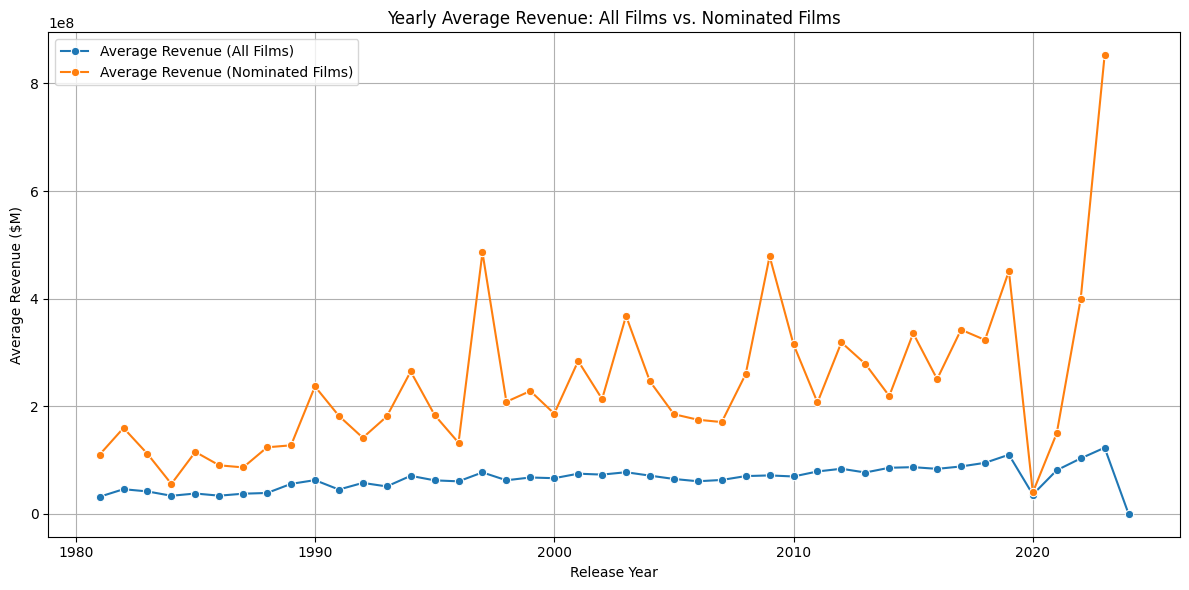

In [244]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_comparison_df, x='release_year', y='avg_revenue_all', label='Average Revenue (All Films)', marker='o')
sns.lineplot(data=yearly_comparison_df, x='release_year', y='avg_revenue_nominated', label='Average Revenue (Nominated Films)', marker='o')
plt.title('Yearly Average Revenue: All Films vs. Nominated Films')
plt.xlabel('Release Year')
plt.ylabel('Average Revenue ($M)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Nominated films earn on average **3.4x** the revenue of the average film released in the same year. This insight is corroborated by the time series chart above, with 2020 being an interesting outlier due to the Pandemic. This finding supports our conclusion from SQL Query #1, that is, that there is a positive correlation between awards success and commercial success.

# How is revenue for nominated films distributed across quartiles formed from nominated films?

## SQL Query 6: Window Function

**Purpose**

This query determines the percent of Oscar-nominated films that fall into each revenue quartile when quartiles are based on all films within the same genre. This is a helpful insight because it measures whether nominated films tend to cluster among the highest earners in their genre rather than being spread evenly across the revenue distribution.

**Methodology/Annotations**
A window function was used to compute within-genre revenue quartiles and add the result to a new column, revenue_quartile, which is then used to summarize where nominated films fall. The result is  interesting because it directly addresses whether Oscar recognition is concentrated among commercially successful films.

**WITH all_films_ranked AS (...):** Starts a common table expression that builds revenue quartiles using all films in each genre, not just nominated films.

**SELECT DISTINCT:** Selects unique movie-genre pairs so the same movie is not repeated within the same genre before quartiles are assigned

**NTILE(4):** Divides films into 4 groups as evenly as possible

**OVER (PARTITION BY mg.genre ORDER BY mg.revenue DESC):** Tells SQL to create the 4 groups separately within each genre, ordering films from highest revenue to lowest

**WITH nominated_films AS (...):** Starts a second common table expression containing only distinct Oscar-nominated films

**SELECT DISTINCT film:** Keeps each nominated film only once, even if it received multiple nominations

**FROM oscars:** Pulls nominated films from the Oscars table

**WHERE film IS NOT NULL:** Excludes Oscar rows with missing film titles.

**1st SELECT**: Summarizes where nominated films fall across the revenue quartiles built from all films

**afr.revenue_quartile:** Returns the quartile number from the ranked all-films table

**COUNT(*) AS nominated_films:** Counts how many nominated films fall into each revenue quartile.

**ROUND(COUNT() * 100.0 / SUM(COUNT()) OVER (), 2):** Calculates the percent of nominated films in each quartile

**COUNT(*) * 100.0** converts the quartile count into a percentage numerator

**SUM(COUNT(*)) OVER ()** adds the quartile counts across all quartiles

**ROUND(..., 2)** rounds the percentage to 2 decimal places

**FROM all_films_ranked afr:** Uses the table where all films have already been assigned a within-genre revenue quartile

**GROUP BY afr.revenue_quartile:** Groups the matched rows by quartile so each quartile gets one summary row

**ORDER BY afr.revenue_quartile:** Sorts the output from quartile 1 through quartile 4

In [245]:
query = """
WITH all_films_ranked AS (
    SELECT DISTINCT
        mg.title,
        mg.genre,
        mg.revenue,
        NTILE(4) OVER (
            PARTITION BY mg.genre
            ORDER BY mg.revenue DESC
        ) AS revenue_quartile
    FROM movie_genre mg
),
nominated_films AS (
    SELECT DISTINCT
        film
    FROM oscars
)
SELECT
    afr.revenue_quartile,
    COUNT(*) AS nominated_films,
    ROUND(
        COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (),
        2
    ) AS pct_of_nominated_films
FROM all_films_ranked afr
JOIN nominated_films nf
    ON afr.title = nf.film
GROUP BY afr.revenue_quartile
ORDER BY afr.revenue_quartile;
"""
revenue_quartile_df = pd.read_sql_query(query, conn)
revenue_quartile_df.head()

,revenue_quartile,nominated_films,pct_of_nominated_films
0,1,1790,57.35
1,2,812,26.02
2,3,384,12.30
3,4,135,4.33


Once again, this corroborates the insight we've found so far: the majority of nominated films fall in the top revenue quartile. Only **4.33%** of nominated films have revenue in the bottom quartile, suggesting that it's really hard to get awards recognition if your film has little commercial success (thus marketing is important!)

# Did the winning film in a category have the highest revenue compared to all nominees in that category?

## SQL Query 7: Window Function

**Purpose**

This query determines the percent of winning films that have the highest revenue compared to other nomations in its category.This is a helpful insight because it measures whether commercial success and award success line up inside each category.

**Methodology**

A window function was used to compute a rank across relatewd rows and add the result to a new column, revenue_rank_in_category, which is needed for the later percentage calculation.

**Annotations**

**Outer SELECT:** Computes one final percentage from the subquery result.

**SUM(CASE WHEN sub.winner = 1 AND sub.revenue_rank_in_category = 1 THEN 1 ELSE 0 END):** Counts how many rows are Oscar winners and have revenue rank 1 within their category. Since rank 1 means highest revenue, this is counting winning films that were the top earners in their category

**CAST(... AS REAL) * 100:** Converts the count into decimal math and multiplies by 100 so the final answer is a percentage.

**/ SUM(CASE WHEN sub.winner = 1 THEN 1 ELSE 0 END):** Divides by the total number of winning-film rows in the subquery to give the share of winners that were also the highest-revenue film in their category.

**FROM ( ... ) AS sub:** Starts a subquery and labels it sub

**Subquery SELECT:** Builds one row per movie-category Oscar record and assigns a revenue rank within category

**ROW_NUMBER() OVER (...):** Window function that assigns a unique rank to each row within a category based on revenue.

**PARTITION BY o.canon_category:** Tells SQL to restart the ranking separately for each Oscar category. So Best Picture films are ranked against other Best Picture films, Best Director films against other Best Director films, etc.

**ORDER BY m.revenue DESC:** Within each category, films are ordered from highest revenue to lowest

**INNER JOIN oscars o:** Joins movie records to Oscar records. An inner join was used because the query only cares about films that appear in both the movie dataset and the Oscars dataset. Unmatched films are irrelevant to this question.

In [247]:
query_winning_revenue_rank = """
SELECT
    CAST(SUM(CASE WHEN sub.winner = 1 AND sub.revenue_rank_in_category = 1 THEN 1 ELSE 0 END) AS REAL) * 100
    / SUM(CASE WHEN sub.winner = 1 THEN 1 ELSE 0 END) AS percentage_winning_films_with_highest_revenue
FROM (
    SELECT
        m.title,
        o.canon_category,
        o.winner,
        m.revenue,
        ROW_NUMBER() OVER (
            PARTITION BY o.canon_category
            ORDER BY m.revenue DESC
        ) AS revenue_rank_in_category
    FROM movies m
    INNER JOIN oscars o
        ON m.title = o.film
) AS sub;
"""

percentage_sql_winning_revenue_df = pd.read_sql_query(query_winning_revenue_rank, conn)
display(percentage_sql_winning_revenue_df)

,percentage_winning_films_with_highest_revenue
0,1.474201


Interestingly, the correlation falls apart once we compare outcomes between nominees. Which nominee gets to win the award seems to be a decision uncorrelated with commercial success, as only **1.47%** of winning films have the highest revenue compared to their nominated peers.

# Do movies by the same director make more money after the director has won their first Oscar?

## SQL Query 8: Join Directors to Oscar-Winning Films

**Purpose**

This query links directors from the movie dataset with Oscar-winning films in the Oscar dataset.

**Methodology/Annotations**

An *Inner Join* is used to match movie titles between the movies table and the oscars table. It is used because the goal is to analyze only movies that appear in both datasets. The join condition compares m.title and o.film. Only rows where the movie exists in both tables are kept. The query then filters the results to include only rows where the Oscar record indicates a winning nomination.

In [248]:
query_director_join = """
SELECT DISTINCT
    md.director,
    md.title,
    md.release_year,
    md.revenue,
    o.category,
    o.winner
FROM movie_director md
JOIN oscars o
    ON md.title = o.film
WHERE o.winner = 1
ORDER BY md.director;
"""

director_winners = pd.read_sql_query(query_director_join, conn)
director_winners.head(10)

,director,title,release_year,revenue,category,winner
0,Adam McKay,the big short,2015,133346506,WRITING (Adapted Screenplay),1
1,Adam McKay,vice,2018,76073488,MAKEUP AND HAIRSTYLING,1
2,Adrian Lyne,flashdance,1983,201500000,MUSIC (Original Song),1
3,Adrian Molina,coco,2017,800526015,ANIMATED FEATURE FILM,1
4,Adrian Molina,coco,2017,800526015,MUSIC (Original Song),1
5,Akira Kurosawa,ran,1985,11859533,COSTUME DESIGN,1
6,Alan J. Pakula,sophies choice,1982,30036000,ACTRESS IN A LEADING ROLE,1
7,Alan Parker,mississippi burning,1988,34604000,CINEMATOGRAPHY,1
8,Alan Parker,evita,1996,141047179,MUSIC (Original Song),1
9,Albert Magnoli,purple rain,1984,68392977,MUSIC (Original Song Score),1


This query identifies directors whose films have won Oscars by linking the movie dataset with the Oscar nomination dataset. The resulting dataset provides information about the directors, the films they directed, the revenue of those films, and the categories in which they won. A user can perform specific queries on this database to see all the awards attributable to a director.

## SQL Query 9: Subquery

**Purpose**

This query compares each director’s average movie revenue before and after the year of their first Oscar win. This is a helpful insight because it measures whether winning an Oscar is associated with a change in the commercial performance of a director’s films over time.

**Methodology/Annotations**

A subquery is used to identify each director’s first_win_year by finding the earliest release year among that director’s Oscar-winning films. That first-win benchmark is then joined back to all films by the same director so the query can separate movies released before the first win from movies released after it.

**SELECT fw.director:** Final result should have one row per director.

**fw:** Alias for the subquery below, short for “first win.”

**First AVG block**: CASE checks each movie row, and if the movie’s release_year is earlier than the director’s first_win_year, it returns that movie’s revenue; otherwise it returns NULL. AVG() then averages those revenues to get the director’s average revenue before the first Oscar win.

**Second AVG block:** CASE checks each movie row, and if the movie’s release_year is later than the director’s first_win_year, it returns that movie’s revenue; otherwise it returns NULL. AVG() then averages those revenues to get the director’s average revenue after the first Oscar win.

**FROM:** Starts a subquery.

**SELECT...FROM block:** Selects the director name and the earliest release year among that director’s Oscar-winning films using MIN(md.release_year) from movie_director. md is the alias for movie_director.

**Subquery INNER JOIN block:** Matches movie titles in movie_director to film titles in oscars. An inner join is used because we only care about movies that appear in the Oscars dataset. o is the alias for oscars.

**WHERE block:** Filters joined rows so only Oscar-winning films are included (o.winner = 1) and director cannot be null.

**GROUP BY block**: Groups rows by director so each director gets one first_win_year.

**Main JOIN block:** Joins the temporary fw table back to all rows in movie_director for that same director.

**Second WHERE block:** Filters out rows where director or release year is null.

**Main GROUP BY:** Groups all rows by director so the before/after revenue averages are calculated per director.

**HAVING block:** Keeps only directors who have at least one movie before the first win year and at least one movie after it, so both averages are meaningful.

**ORDER BY:** Sorts results from highest to lowest average revenue after win.

In [249]:
query_director_before_after = """
SELECT
    fw.director,
    AVG(
        CASE
            WHEN md.release_year < fw.first_win_year
            THEN md.revenue
        END
    ) AS avg_revenue_before_win,
    AVG(
        CASE
            WHEN md.release_year > fw.first_win_year
            THEN md.revenue
        END
    ) AS avg_revenue_after_win
FROM (
    SELECT
        md.director,
        MIN(md.release_year) AS first_win_year
    FROM movie_director md
    JOIN oscars o
        ON md.title = o.film
    WHERE o.winner = 1
    GROUP BY md.director
) fw
JOIN movie_director md
    ON md.director = fw.director
GROUP BY fw.director
HAVING avg_revenue_before_win IS NOT NULL
   AND avg_revenue_after_win IS NOT NULL
ORDER BY avg_revenue_after_win DESC;
"""

director_before_after = pd.read_sql_query(query_director_before_after, conn)
director_before_after

,director,avg_revenue_before_win,avg_revenue_after_win
0,Jon Favreau,2.465072e+08,1.663075e+09
1,Greta Gerwig,7.896649e+07,1.428545e+09
2,James Cameron,7.837120e+07,1.216292e+09
3,J.J. Abrams,3.984795e+08,9.674573e+08
4,Lee Unkrich,4.973669e+08,9.359438e+08
...,...,...,...
125,Paolo Sorrentino,1.152567e+07,2.000000e+06
126,Alfonso Cuarón,1.607306e+08,1.140769e+06
127,Paul Schrader,5.027580e+05,1.097308e+06
128,David Ayer,7.090291e+07,9.426660e+05


In [250]:
print("Average revenue before win:", director_before_after.avg_revenue_before_win.mean())
print("Average revenue after win:", director_before_after.avg_revenue_after_win.mean())
print(f"Post win revenue premium: {director_before_after.avg_revenue_after_win.mean() / director_before_after.avg_revenue_before_win.mean()}x")

Average revenue before win: 79571519.1078022
Average revenue after win: 209396579.49245635
Post win revenue premium: 2.6315518647918394x


Similar to production companies, movies made by directors after they win an Oscar are likely to be more commercially successful. The relationship is in fact stronger here, with a **263% increase in grossing** compared to before. This suggests that **it is important to identify directors who have just won their first Oscar/experienced their first major career success**, as their following works are likely to be commercial hits.

# Do movies by the same actor/actress make more money after the actor/actress has won their first Oscar?

## SQL Query 10: Subquery

**Purpose**

This query compares each actor’s average movie revenue before and after the year of their first Oscar win. This is a helpful insight because it measures whether winning an Oscar is associated with a change in the commercial performance of an actor’s films over time.

**Methodology/Annotations**

A subquery is used to identify each actor’s first_win_year by finding the earliest release year among that actor’s Oscar-winning records in the oscars table. That first-win benchmark is then joined back to all films by the same actor in movie_cast so the query can separate movies released before the first win from movies released after it.

**SELECT fw.actor:** Final result should have one row per actor.

**fw:** Alias for the subquery below, short for “first win.”

**First AVG block:** CASE checks each movie row, and if the movie’s release_year is earlier than the actor’s first_win_year, it returns that movie’s revenue; otherwise it returns NULL. AVG() then averages those revenues to get the actor’s average revenue before the first Oscar win.

**Second AVG block**: CASE checks each movie row, and if the movie’s release_year is later than the actor’s first_win_year, it returns that movie’s revenue; otherwise it returns NULL. AVG() then averages those revenues to get the actor’s average revenue after the first Oscar win.

**FROM**: Starts a subquery.

**SELECT...FROM block:** Selects the actor name and the earliest release year among that actor’s Oscar-winning records using MIN(release_year) from oscars. name is renamed as actor.

**Subquery WHERE block:** Filters rows so only Oscar-winning records are included (winner = 1) and actor name cannot be null.

**GROUP BY block:** Groups rows by actor so each actor gets one first_win_year.

**Main JOIN block:** Joins the temporary fw table to all rows in movie_cast for that same actor using mc.ind_cast = fw.actor.

**Second WHERE block: **Filters out rows where actor name or release year is null.

**Main GROUP BY:** Groups all rows by actor so the before/after revenue averages are calculated per actor.

**HAVING block**: Keeps only actors who have at least one movie before the first win year and at least one movie after it, so both averages are meaningful.

**ORDER BY:** Sorts results from highest to lowest average revenue after win.

In [253]:
query_actor_before_after = """
SELECT
    fw.actor,
    AVG(
        CASE
            WHEN mc.release_year < fw.first_win_year
            THEN mc.revenue
        END
    ) AS avg_revenue_before_win,
    AVG(
        CASE
            WHEN mc.release_year > fw.first_win_year
            THEN mc.revenue
        END
    ) AS avg_revenue_after_win
FROM (
    SELECT
        name AS actor,
        MIN(release_year) AS first_win_year
    FROM oscars
    WHERE winner = 1
    GROUP BY name
) fw
JOIN movie_cast mc
    ON mc.ind_cast = fw.actor
GROUP BY fw.actor
HAVING avg_revenue_before_win IS NOT NULL
   AND avg_revenue_after_win IS NOT NULL
ORDER BY avg_revenue_after_win DESC;
"""

query_actor_before_after = pd.read_sql_query(query_actor_before_after, conn)
query_actor_before_after

,actor,avg_revenue_before_win,avg_revenue_after_win
0,Jordan Peele,7.571640e+07,1.073395e+09
1,Laura Dern,9.659727e+07,1.001978e+09
2,James Earl Jones,1.324339e+08,8.322177e+08
3,Angela Lansbury,1.634357e+08,5.085753e+08
4,Rami Malek,1.490964e+08,4.973016e+08
...,...,...,...
133,Samuel L. Jackson,2.132066e+08,2.148819e+07
134,Gary Oldman,2.398673e+08,1.589746e+07
135,Joaquin Phoenix,1.026545e+08,7.150000e+06
136,Jack Palance,1.731614e+08,4.885850e+06


In [254]:
print("Average revenue before win:", query_actor_before_after.avg_revenue_before_win.mean())
print("Average revenue after win:", query_actor_before_after.avg_revenue_after_win.mean())
print(f"Post win revenue premium: {query_actor_before_after.avg_revenue_after_win.mean() / query_actor_before_after.avg_revenue_before_win.mean()}x")

Average revenue before win: 86350141.6580636
Average revenue after win: 174193943.76705214
Post win revenue premium: 2.0172977185936722x


The results here are similar to those of directors. Movies where an actor/actress act in after they win an Oscar are likely to be more commercially successful. The relationship is weaker than that of directors but still very strong, with a **201% increase in grossing** compared to before. This suggests that **it is important to identify actors/actresses who have just won their first Oscar/experienced their first major career success**, as their following works are likely to be commercial hits. Actors/actresses may also be an easier cohort to target as they have more flexibility between production companies than directors do, and there are slightly more of them.

# Conclusion

The research undertook an analysis of how various aspects of the movie industry, including budget, ratings, genres, and time of release, impact the success of the film in terms of revenue and ROI. The results of the analysis and regression showed that the budget of the film has a significant impact on the revenue generated at the box office. Thus, the bigger the budget of the movie, the more revenue is harvested at the box office. The analysis also showed that the movie industry is marked by high variance, where only a handful of blockbuster movies contribute significantly to the overall profits earned in the industry.

However, the situation is not as simple as just spending more and earning more. Even though the highest revenue-earning movies have the highest budget, the ROI is not always directly correlated with the budget spent. The ROI may not increase with the budget; in fact, the ROI may be low or may actually decrease with the increase in the budget. Thus, the movie industry is marked by high risk and high reward, where the blockbusters may bring in high revenue but at the same time carry high financial risks. However, certain genres of the industry, like the comedy genre, may bring in high ROI with relatively low budgets spent.

The predictive models are in line with the results obtained from the analysis. The linear regression is successful in explaining the revenue earned by the movie, and the results obtained from the logistic regression are quite accurate in determining the overall success of the movie. Thus, it can be said that the factors affecting the movie industry are quite significant in determining the financial success of the movie, although they cannot be said to be responsible for the wild card that is the success of the movie. However, more time and data may be used to include aspects like the marketing and distribution costs of the movie, the release of the movie in relation to the competition, and the popularity of the actors in the movie.

Shifting to the SQL analysis, which focused on the relationship between Oscar awards success and commercial success, we see a curious dynamic. At the broadest level, nominated films earn, on average, 3.4 times the revenue of the average film released in the same year, and the majority of nominated films fall in the top revenue quartile, while only 4.33% of nominated films appear in the bottom quartile. Taken together, these findings suggest that awards recognition is rarely detached from commercial scale. If a producer aspires to awards recognition, they cannot rely on quality alone but also sufficient scale and marketing support to avoid being stranded in the low-revenue segment where recognition is rare.

The conclusion about genre recommendation is more unclear. Drama offers the largest absolute pathway into nomination culture, but not necessarily the highest probability of recognition on a per-film basis. Genres with more specialized category structures may offer a more efficient route to awards attention, especially for producers operating with constrained resources and seeking strategic rather than maximal exposure.

The most consequential and actionable finding comes from analysis of post-award talent success. Not only does awards recognition have a durable association with future commercial performance at the production company level, but the same pattern becomes even stronger at the director level: films made by directors after their first Oscar win show a 263% increase in grossing relative to their pre-win baseline. The pattern also holds for actors and actresses, whose post-win films show a 201% increase in grossing. These are large jumps, and they suggest that an Oscar win increases future market value. For producers, the most actionable insight is that talent right after a first major awards breakthrough may be especially valuable. In particular, newly crowned Oscar-winning actors/actresses may constitute a more flexible and scalable target because they move more easily across projects, studios, and production structures.

This analysis is fairly cursory in nature and can be improved by at least two means:

1) The ‘budget’ column only accounts for production budget, yet distribution and marketing spend can have a significant impact on revenue and popularity. Including marketing spend can help us form a more comprehensive view on ROI.

2) We don’t factor in release timing and competing releases. The way that movie releases interact with each other can crowd out revenue and impact the bottom line. Adding release calendars and the number of competing wide releases would help isolate whether outcomes were driven by a film’s own appeal vs. the environment it entered.

Ultimately, this study points to the conclusion that film success emerges from a mix of financial scale, strategic positioning, and market perception. While commercial performance and prestige are often connected, they are not perfectly aligned, and producers are best served by first identifying what they want their film to "be", which impacts how they think through certain trade-offs.